In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:

def linear_alpha_sq(min,max,t):
    return np.exp(-(min *t + (t**2) *(1/2)*(max-min)))

def f(t,s):
    return np.cos((np.pi/2)*(t+s)/ (1+s)) **2
def cosine_alpha_sq(t,s):
    return f(t,s)/ f(0,s)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_alpha_sq(t, start=-3, end=6, tau=1.0):
    v_start = sigmoid(start / tau)
    v_end = sigmoid(end / tau)
    f_t = sigmoid((t * (end - start) + start) / tau)
    return (v_end - f_t) / (v_end - v_start)

def SNR(f):
    return f/(1-f+1e-10)

def info(snr):
    return np.log(1+snr)

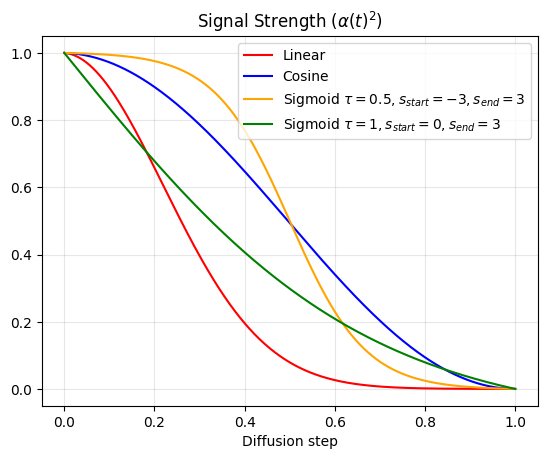

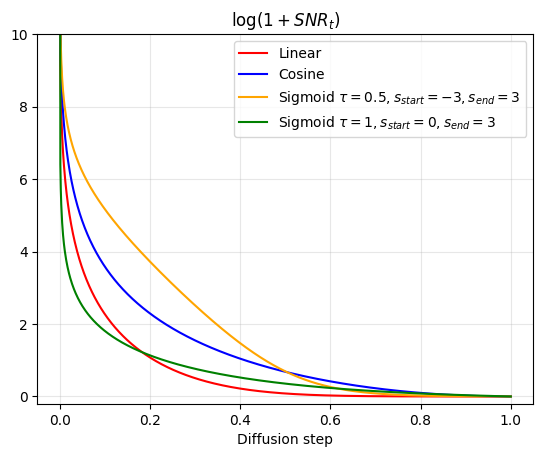

In [ ]:
x = np.linspace(0,1,1000)
s = 0.008
beta_min, beta_max = 0.1, 20.0

asq_lin = linear_alpha_sq(beta_min, beta_max,x)
asq_cos = cosine_alpha_sq(x, s)
asq_sig0 = sigmoid_alpha_sq(x,tau=0.5,start=-3,end=3)
asq_sig1 = sigmoid_alpha_sq(x,tau=1,start=0,end=3)
snr_lin = SNR(asq_lin)
snr_cos = SNR(asq_cos)
snr_sig0 = SNR(asq_sig0)
snr_sig1 = SNR(asq_sig1)

info_lin = info(snr_lin)
info_cos = info(snr_cos)
info_sig0 = info(snr_sig0)
info_sig1 = info(snr_sig1)


plt.plot(x, asq_lin, label='Linear', color='red')
plt.plot(x, asq_cos, label='Cosine', color='blue')
plt.plot(x,asq_sig0, label =r"Sigmoid $\tau =0.5, s_{start} =-3, s_{end}=3$", color="orange")
plt.plot(x,asq_sig1, label =r"Sigmoid $\tau =1, s_{start} =0, s_{end}=3$", color="green")
plt.title(r'Signal Strength ($\alpha(t)^2$)')
plt.legend()
plt.xlabel("Diffusion step")
plt.grid(True, alpha=0.3)
plt.show()


plt.plot(x, info_lin, color='red', label='Linear')
plt.plot(x, info_cos, color='blue', label='Cosine')
plt.plot(x,info_sig0, label =r"Sigmoid $\tau =0.5, s_{start} =-3, s_{end}=3$", color="orange")
plt.plot(x,info_sig1, label =r"Sigmoid $\tau =1, s_{start} =0, s_{end}=3$", color="green")
plt.title(r'$\log(1+SNR_t)$')
plt.legend()
plt.ylim(-0.2,10)
plt.xlabel("Diffusion step")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:

def apply_diffusion_noise(image_array, gamma):

    noise = np.random.normal(0, 1, image_array.shape)
    noisy_image = np.sqrt(gamma) * image_array + np.sqrt(1 - gamma) * noise
    
    return np.clip(noisy_image, 0., 1.)

def run_experiment(image, gamma_value=0.7):
    original_img = image
    resolutions = [64, 128, 256, 512, 1024, 2048]
    
    fig, axes = plt.subplots(1, len(resolutions), figsize=(15, 4))
    
    for ax, res in zip(axes, resolutions):
        img_resized = original_img.resize((res, res), Image.Resampling.LANCZOS)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        noisy_img_array = apply_diffusion_noise(img_array, gamma_value)
        ax.imshow(noisy_img_array)
        ax.set_title(f"{res} x {res}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [63]:
import requests
from PIL import Image
from io import BytesIO

url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d?w=2048"

response = requests.get(url)
img = Image.open(BytesIO(response.content))


img.show()

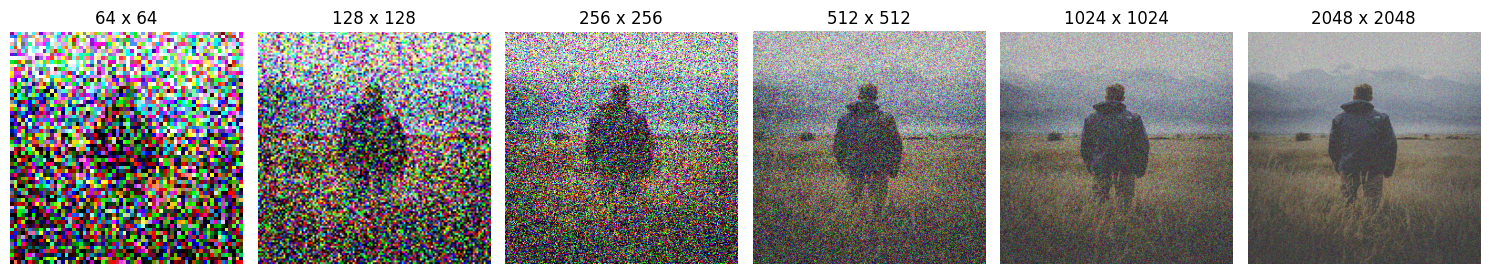

In [64]:
run_experiment(img)